In [1]:
import matplotlib.pyplot as plt 
import matplotlib
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text
import numpy as np
from scipy.spatial.distance import jensenshannon

In [2]:
def hist_obs_sim(cell_count, infer_cell_count,
                 xlab='Cell2location cell proportion',
                 ylab='Inferred cell proportion',
                 title='', compute_kl=True, equal=True):
    
    plt.rcParams.update({'font.size': 12})  # Increase font size
    cor = np.round(np.corrcoef(cell_count.flatten(), infer_cell_count.flatten()), 3)[0,1]
    max_val = np.concatenate([cell_count.flatten(), infer_cell_count.flatten()]).max()
    title = title +'\n'+ r'Pearson R: ' + str(cor)
    
    if compute_kl:
        js = np.array([jensenshannon(cell_count[r,:], infer_cell_count[r,:]) 
                 for r in range(cell_count.shape[0])])
        js = np.mean(js[~np.isnan(js)])
        title = title + '\nAverage JSD: ' + str(np.round(js, 2))

    if np.max(cell_count) > 1:
        x_bins = int(np.max(cell_count))
        max_val = np.max(cell_count)
    else:
        x_bins = 35
        max_val = np.max(cell_count)

    fig, ax = plt.subplots()
    h = ax.hist2d(x=cell_count.flatten(), 
                  y=infer_cell_count.flatten(),
                  bins=[x_bins, 35], 
                  norm=matplotlib.colors.LogNorm())
                #   cmap='plasma')  # Change color map

    plt.xlabel(xlab)
    plt.ylabel(ylab)
    if equal:
        plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.title(title)
    
    # Add color bar
    cbar = plt.colorbar(h[3], ax=ax, shrink=0.6)
    cbar.set_label('Frequency')

    # plt.show()

In [3]:
from glob import glob
tif_list = glob('/data1/r20user3/shared_project/Hist2Cell/code/training/train_test_splits/humanlung_cell2location/test*')
tif_list.sort()
test_slides = list()
for tif in tif_list:
    tif_path = tif.split('_')[-1].split('.')[0]
    test_slides.append(tif_path)
test_slides

['A37', 'A42', 'A48', 'A50']

/tmp/ipykernel_1946029/2485801395.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(4, 4))


<Figure size 400x400 with 0 Axes>

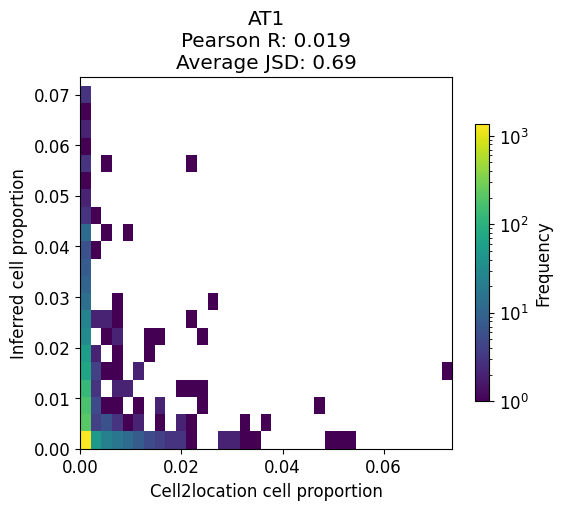

<Figure size 400x400 with 0 Axes>

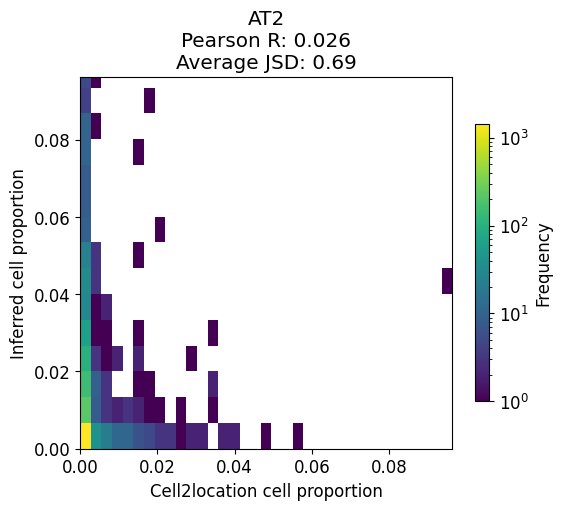

<Figure size 400x400 with 0 Axes>

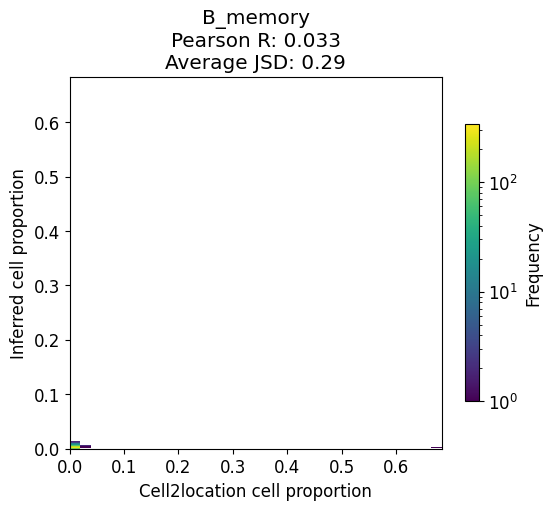

<Figure size 400x400 with 0 Axes>

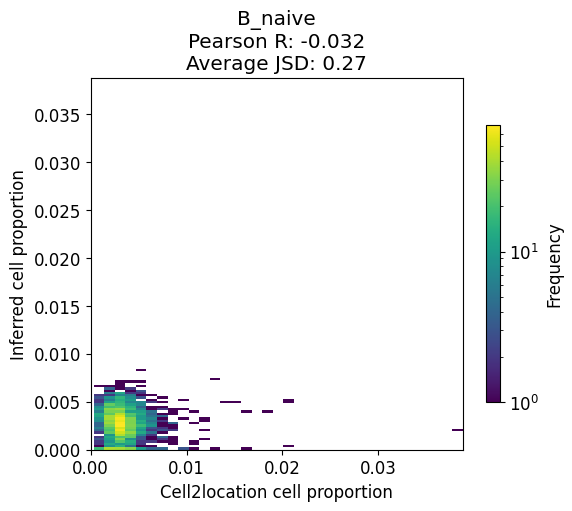

<Figure size 400x400 with 0 Axes>

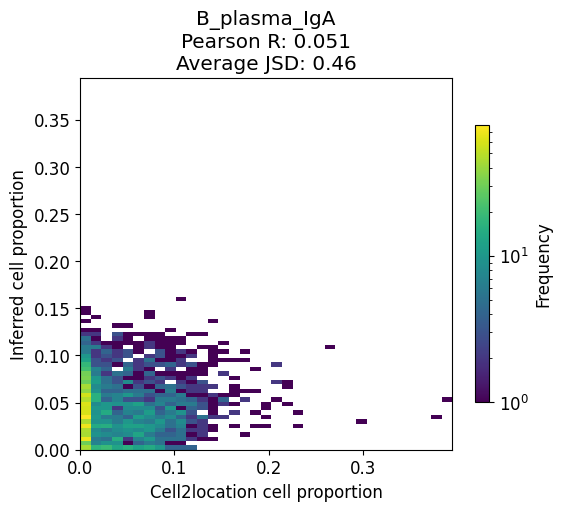

<Figure size 400x400 with 0 Axes>

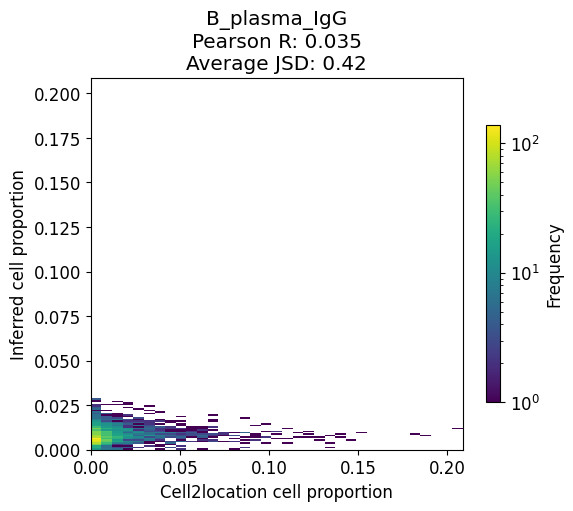

<Figure size 400x400 with 0 Axes>

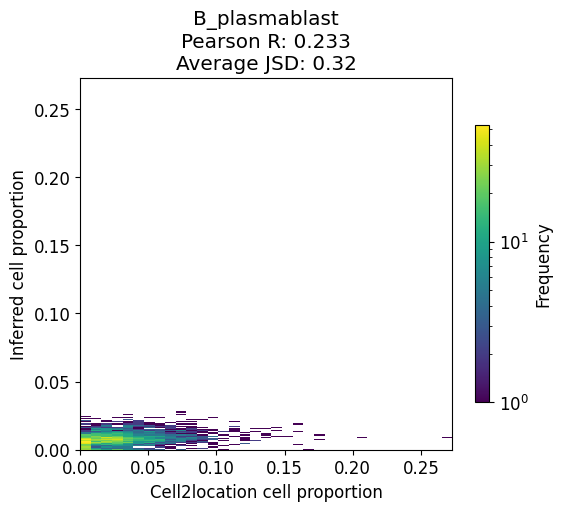

<Figure size 400x400 with 0 Axes>

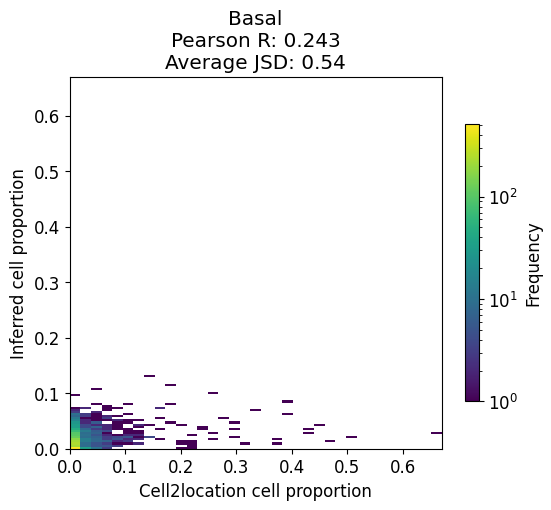

<Figure size 400x400 with 0 Axes>

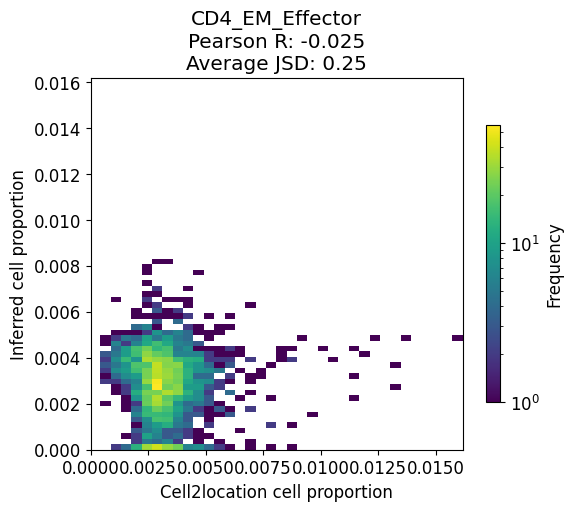

<Figure size 400x400 with 0 Axes>

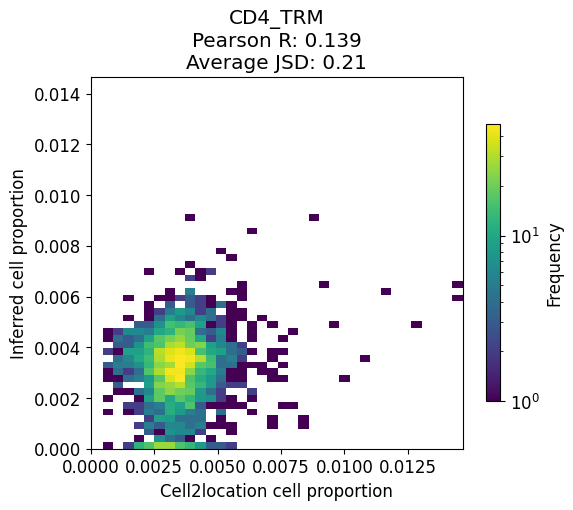

<Figure size 400x400 with 0 Axes>

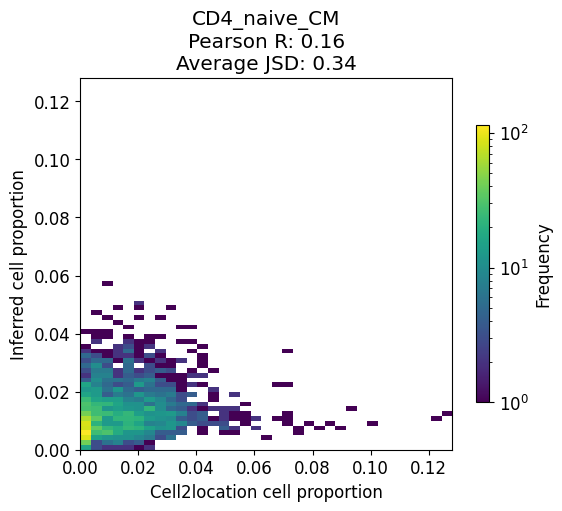

<Figure size 400x400 with 0 Axes>

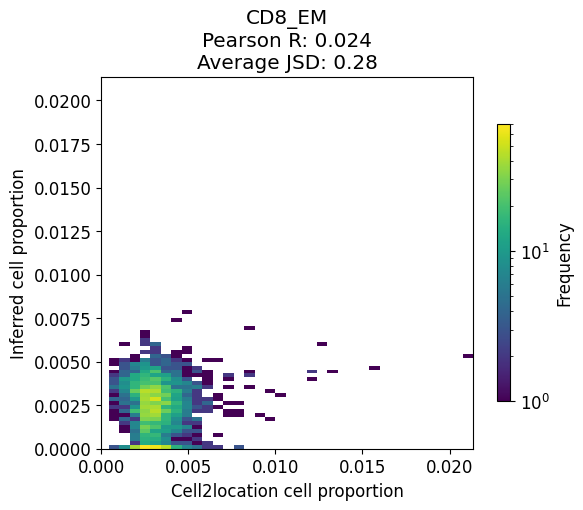

<Figure size 400x400 with 0 Axes>

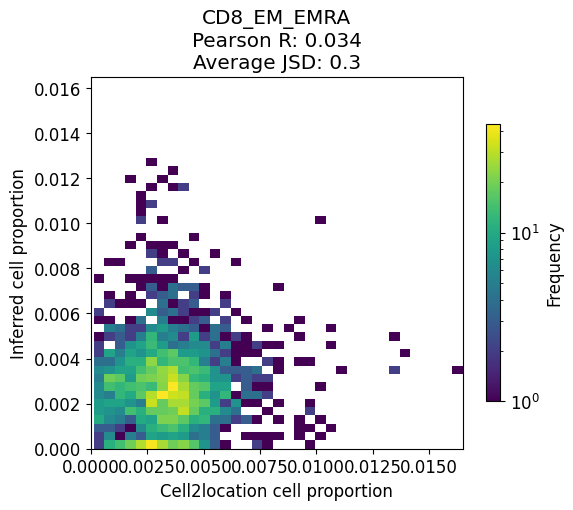

<Figure size 400x400 with 0 Axes>

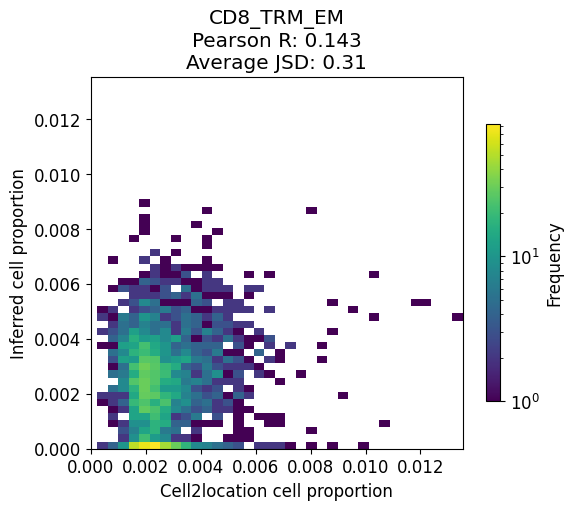

<Figure size 400x400 with 0 Axes>

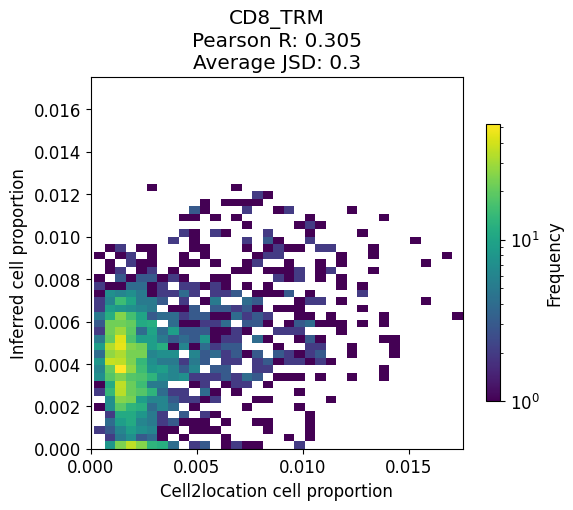

<Figure size 400x400 with 0 Axes>

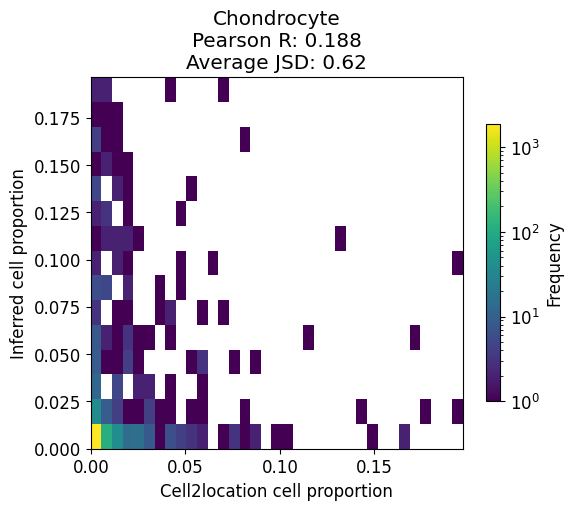

<Figure size 400x400 with 0 Axes>

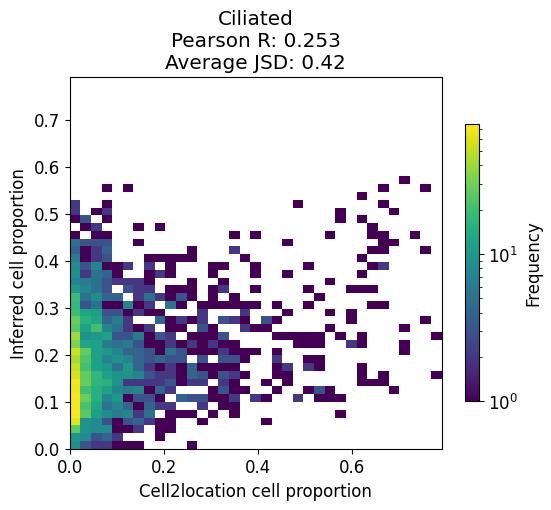

<Figure size 400x400 with 0 Axes>

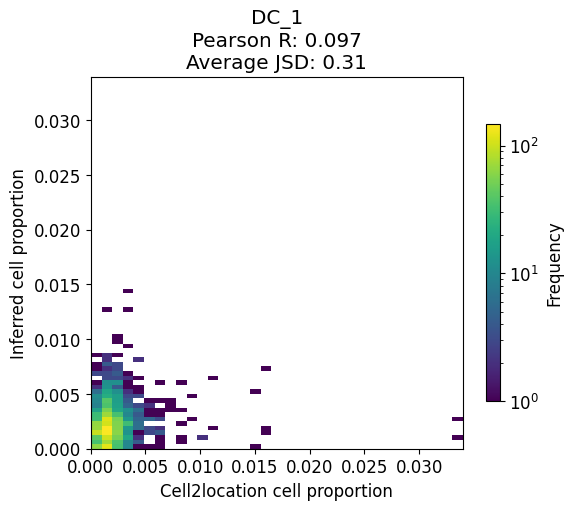

<Figure size 400x400 with 0 Axes>

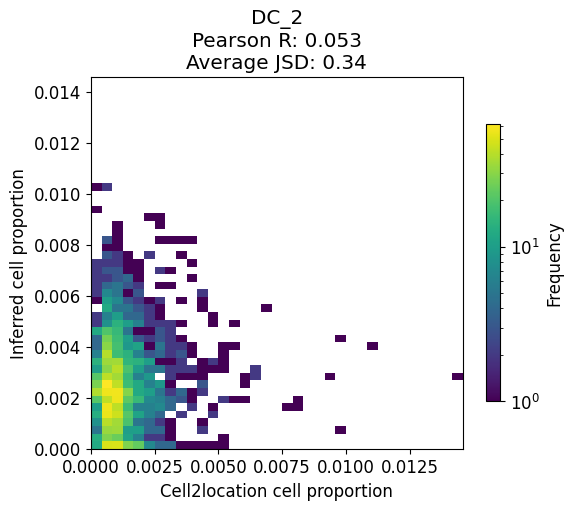

<Figure size 400x400 with 0 Axes>

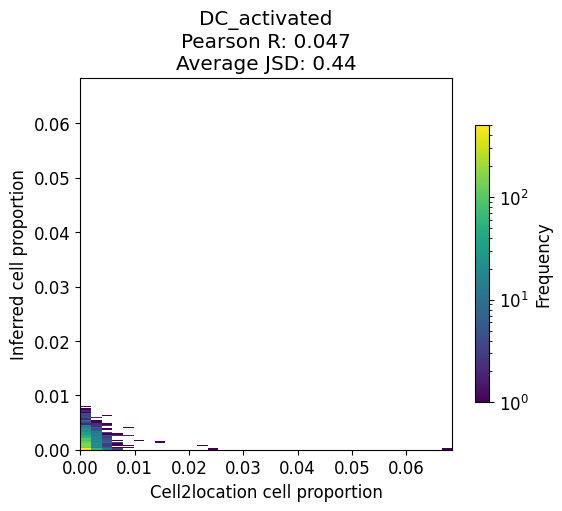

<Figure size 400x400 with 0 Axes>

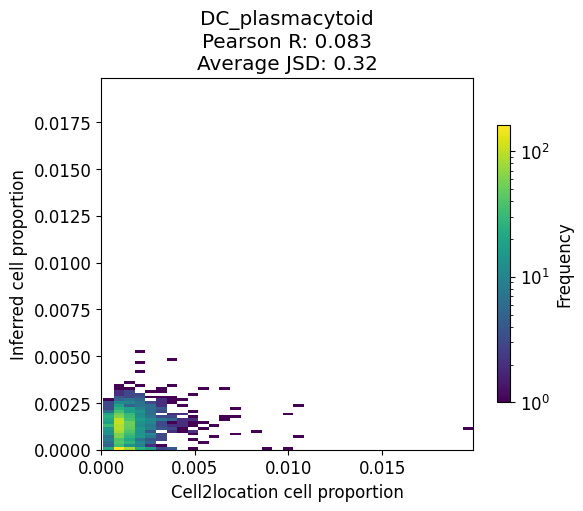

<Figure size 400x400 with 0 Axes>

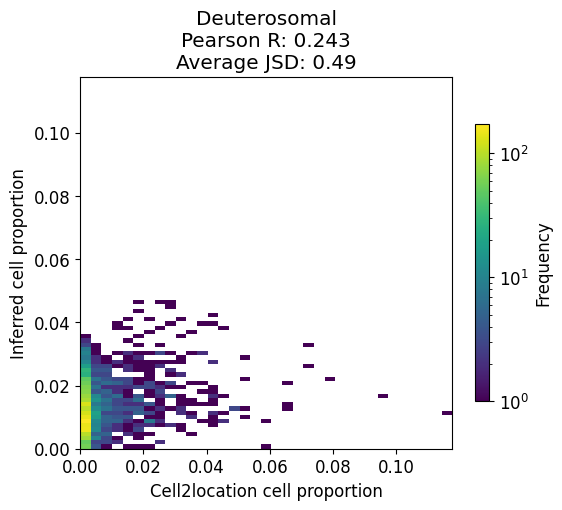

<Figure size 400x400 with 0 Axes>

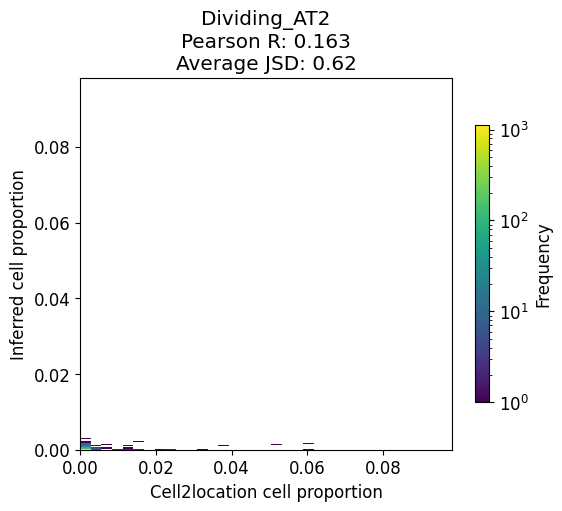

<Figure size 400x400 with 0 Axes>

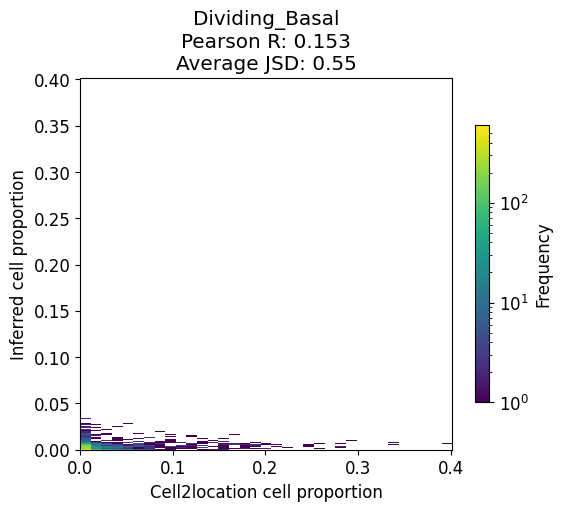

<Figure size 400x400 with 0 Axes>

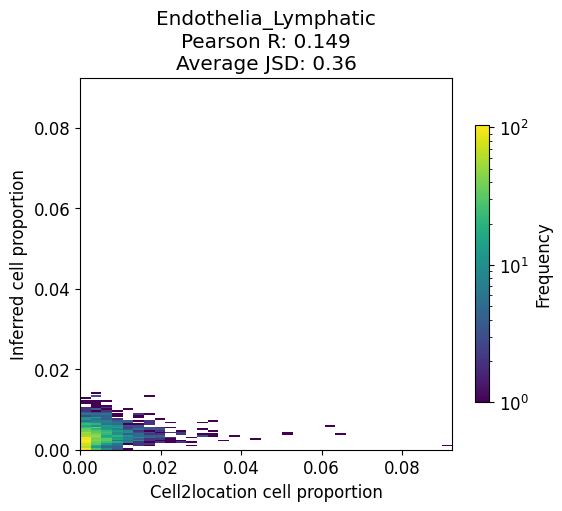

<Figure size 400x400 with 0 Axes>

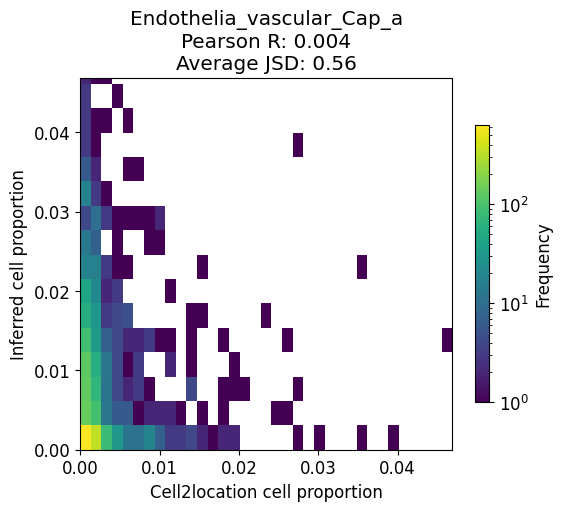

<Figure size 400x400 with 0 Axes>

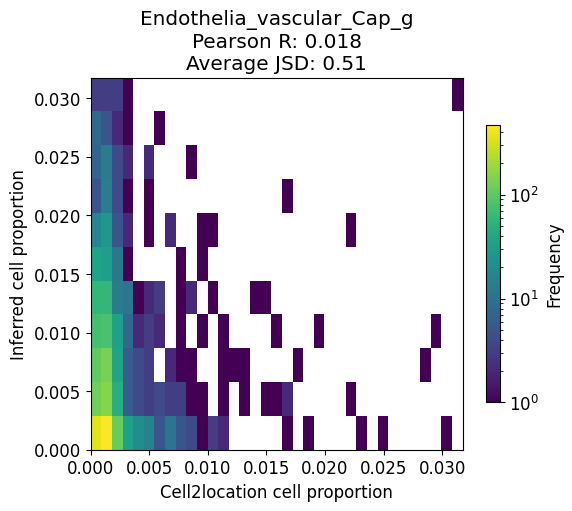

<Figure size 400x400 with 0 Axes>

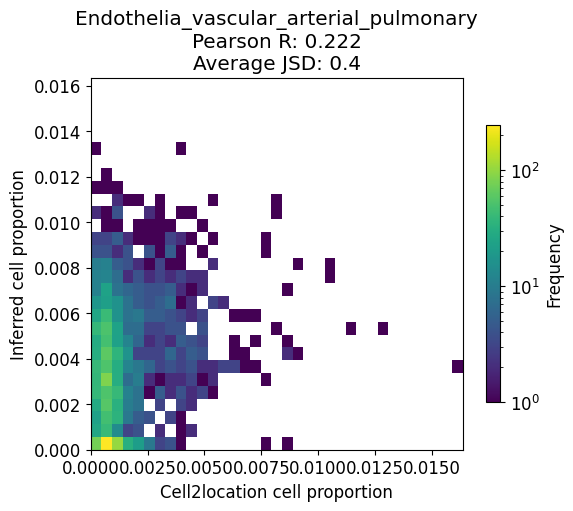

<Figure size 400x400 with 0 Axes>

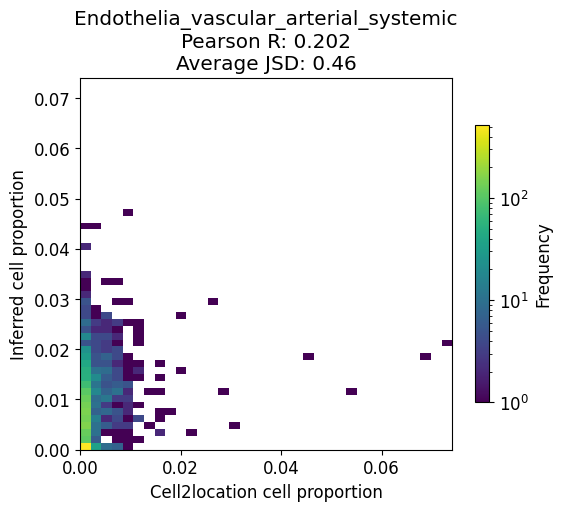

<Figure size 400x400 with 0 Axes>

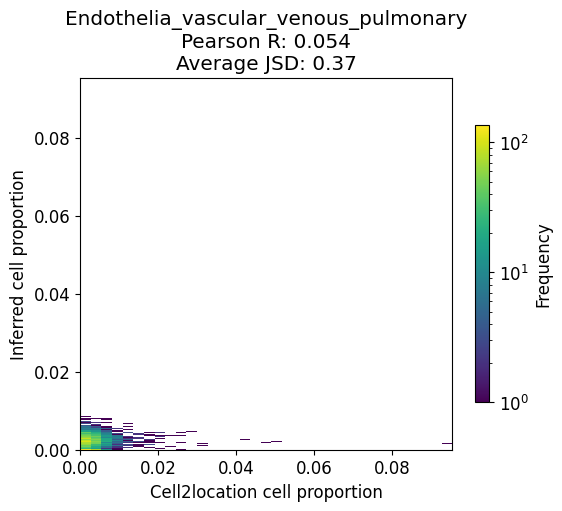

<Figure size 400x400 with 0 Axes>

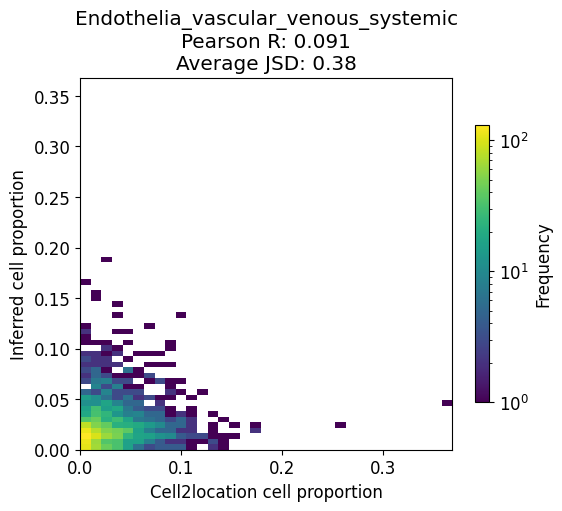

<Figure size 400x400 with 0 Axes>

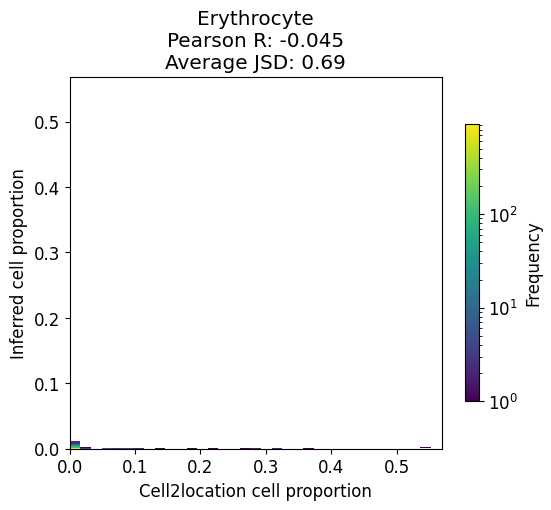

<Figure size 400x400 with 0 Axes>

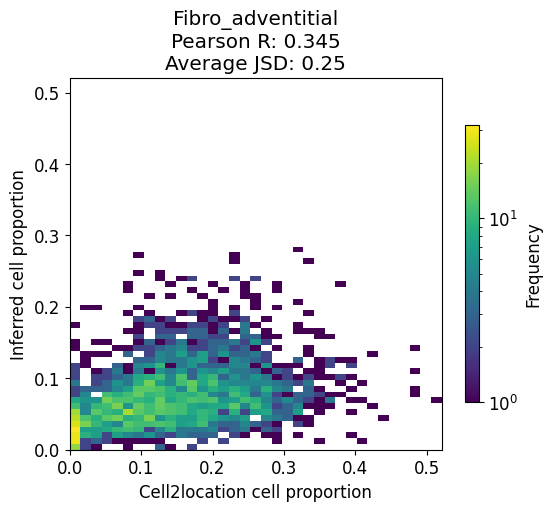

<Figure size 400x400 with 0 Axes>

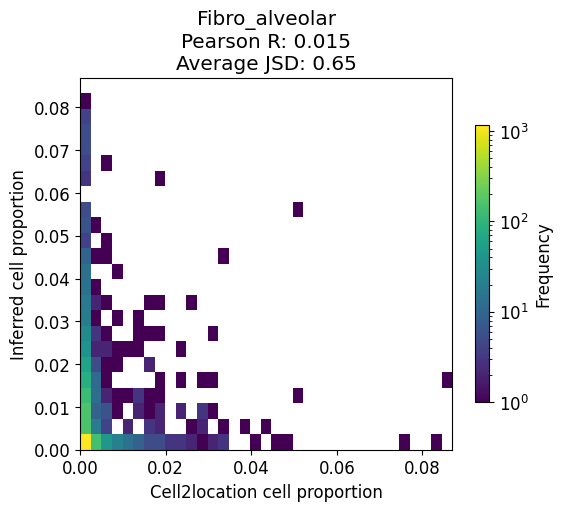

<Figure size 400x400 with 0 Axes>

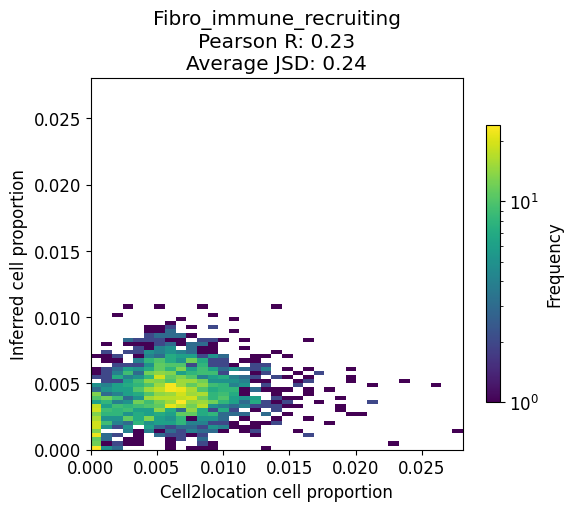

<Figure size 400x400 with 0 Axes>

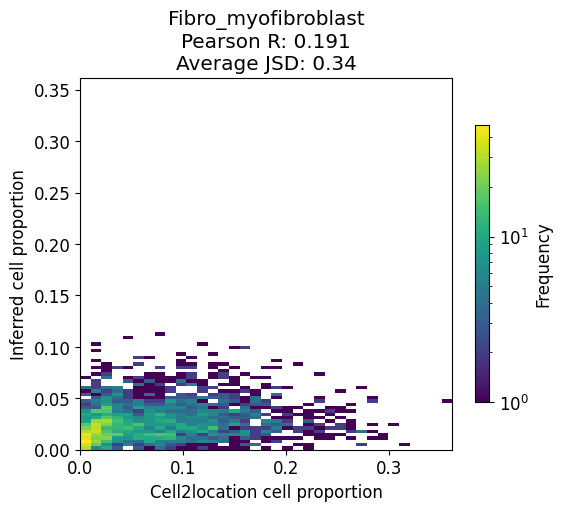

<Figure size 400x400 with 0 Axes>

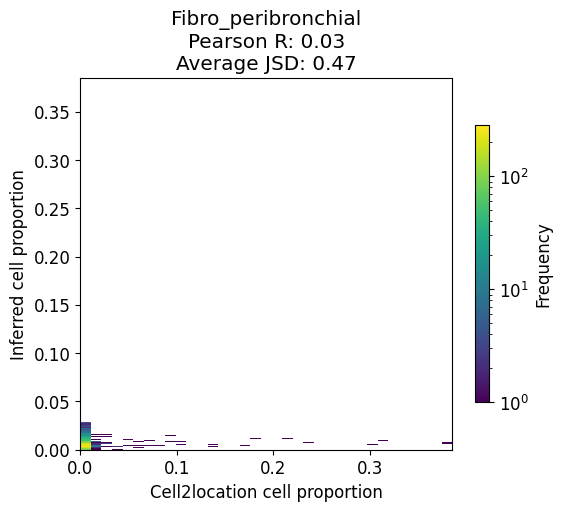

<Figure size 400x400 with 0 Axes>

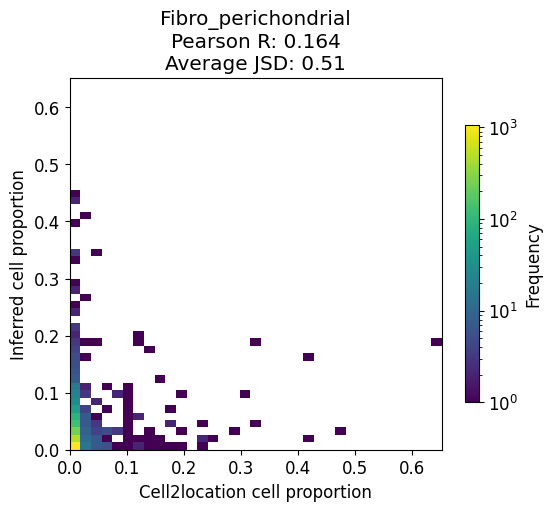

<Figure size 400x400 with 0 Axes>

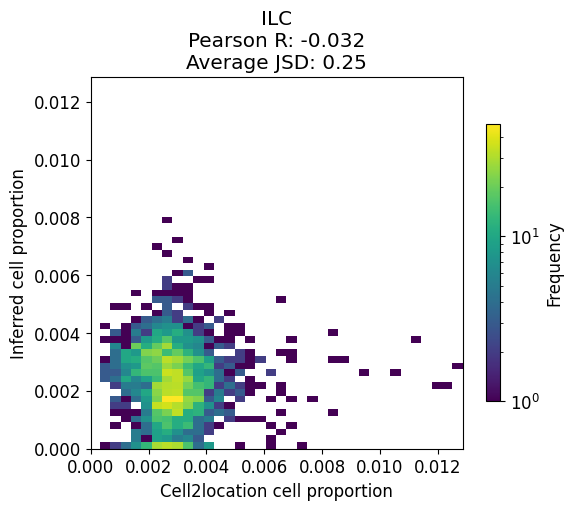

<Figure size 400x400 with 0 Axes>

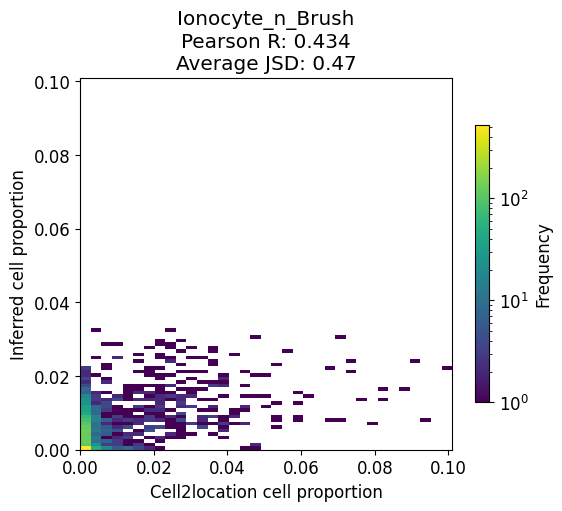

<Figure size 400x400 with 0 Axes>

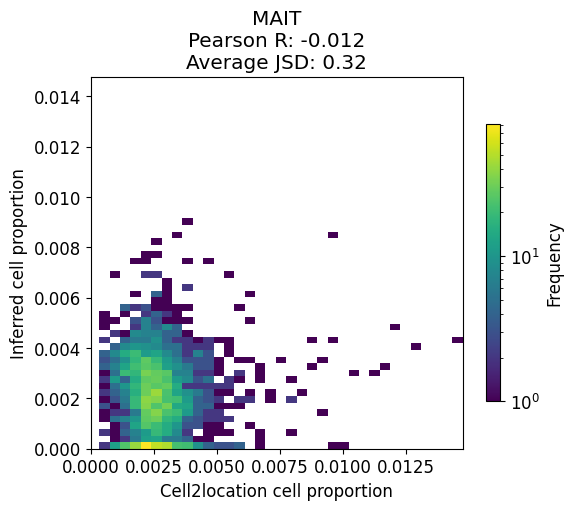

<Figure size 400x400 with 0 Axes>

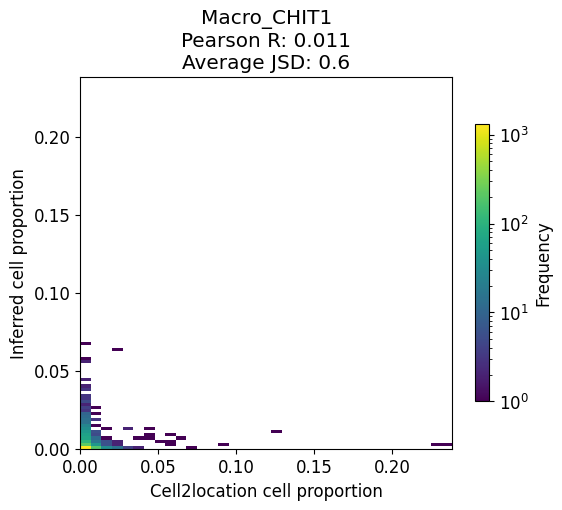

<Figure size 400x400 with 0 Axes>

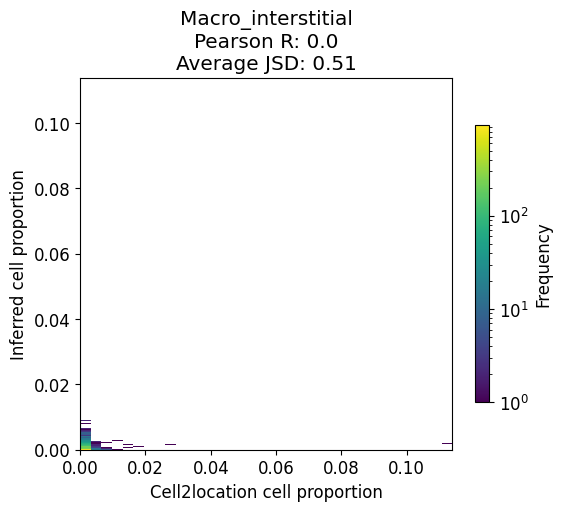

<Figure size 400x400 with 0 Axes>

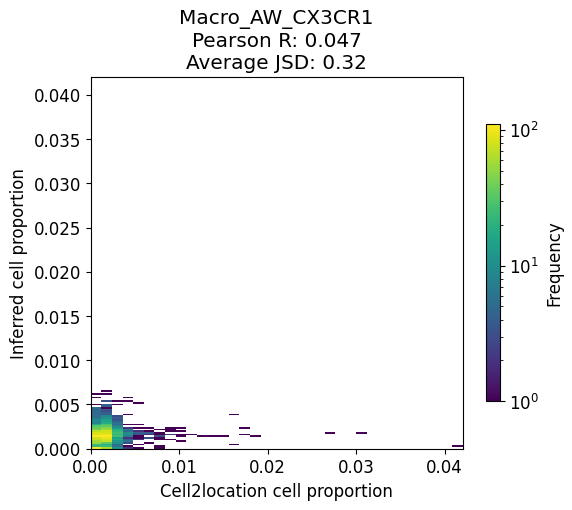

<Figure size 400x400 with 0 Axes>

In [4]:
import joblib
import pandas as pd
import os

cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759311/cell_ratio.csv").columns)[1:]]
for case in test_slides:
    os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_humanlung", case))
    
    save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
    pred_and_label = joblib.load(save_path)
    
    case_pred = list()
    case_label = list()
    
    for slide in pred_and_label:
        os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_humanlung", case, slide))
        
        pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
        pred_ratio = pred_and_label[slide]['cell_abundance_predictions'] / pred_and_label[slide]['cell_abundance_predictions'].sum(axis=1, keepdims=True)
        real_ratio = pred_and_label[slide]['cell_abundance_labels'] / pred_and_label[slide]['cell_abundance_labels'].sum(axis=1, keepdims=True)
        
        os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_humanlung", case, slide, "cell proportion"))
        for i in range(80):
            plt.figure(figsize=(4, 4))
            x = pred_ratio[:,[i]]
            x = np.expand_dims(x, axis=0)
            y = real_ratio[:,[i]]
            y = np.expand_dims(y, axis=0)
            rcParams['figure.figsize'] = 6, 6
            rcParams["axes.facecolor"] = "white"
            
            hist_obs_sim(cell_count=y, infer_cell_count=x, equal=True, title=cell_names[i])
            
            plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_humanlung", case, slide, "cell proportion", cell_names[i]+".png"))
            
        os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_humanlung", case, slide, "cell abundance"))
        for i in range(80):
            plt.figure(figsize=(4, 4))
            x = pred_and_label[slide]['cell_abundance_predictions'][:,[i]]
            x = np.expand_dims(x, axis=0)
            y = pred_and_label[slide]['cell_abundance_labels'][:,[i]]
            y = np.expand_dims(y, axis=0)
            rcParams['figure.figsize'] = 6, 6
            rcParams["axes.facecolor"] = "white"
            
            hist_obs_sim(cell_count=y, infer_cell_count=x, equal=True, title=cell_names[i])
            
            plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_humanlung", case, slide, "cell abundance", cell_names[i]+".png"))
        
        case_pred.append(pred_and_label[slide]['cell_abundance_predictions'])
        case_label.append(pred_and_label[slide]['cell_abundance_labels'])
    
    case_pred = np.concatenate(case_pred)
    case_label = np.concatenate(case_label)
    pred_ratio = case_pred / case_pred.sum(axis=1, keepdims=True)
    real_ratio = case_label / case_label.sum(axis=1, keepdims=True)
    os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_humanlung", case, "cell proportion"))
    for i in range(80):
        plt.figure(figsize=(4, 4))
        x = pred_ratio[:,[i]]
        x = np.expand_dims(x, axis=0)
        y = real_ratio[:,[i]]
        y = np.expand_dims(y, axis=0)
        rcParams['figure.figsize'] = 6, 6
        rcParams["axes.facecolor"] = "white"
        
        hist_obs_sim(cell_count=y, infer_cell_count=x, equal=True, title=cell_names[i])
        
        plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_humanlung", case, "cell proportion", cell_names[i]+".png"))
        
    os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_humanlung", case, "cell abundance"))
    for i in range(80):
        plt.figure(figsize=(4, 4))
        x = case_pred[:,[i]]
        x = np.expand_dims(x, axis=0)
        y = real_ratio[:,[i]]
        y = np.expand_dims(y, axis=0)
        rcParams['figure.figsize'] = 6, 6
        rcParams["axes.facecolor"] = "white"
        
        hist_obs_sim(cell_count=y, infer_cell_count=x, equal=True, title=cell_names[i])
        
        plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_scatter_plot_each_case_humanlung", case, "cell abundance", cell_names[i]+".png"))